## Question 1

In [1]:
import numpy as np  # arrays
import matplotlib.pyplot as plt  # 2d plotting
from mpl_toolkits.mplot3d import axes3d  # 3d plotting

f = lambda x1, x2: 100*(x2-x1**2)**2 + (1-x1)**2
f(1,1)

0

In [28]:
X1 = np.linspace(-2,2,100)
X2 = np.linspace(-2,3,100)
X1mesh, X2mesh = np.meshgrid(X1,X2)
Z = f(X1mesh, X2mesh)

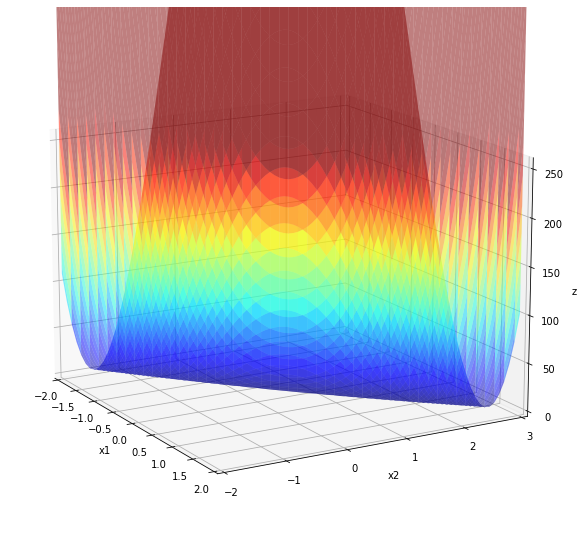

In [30]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d', elev=15, azim=-30)
ax.plot_surface(X1, X2, Z, cmap='jet', alpha=0.5, vmax=250)
ax.set(xlabel='x1', ylabel='x2', zlabel='z', xlim=[-2,2], ylim=[-2,3], zlim=[0, 256])
plt.show()

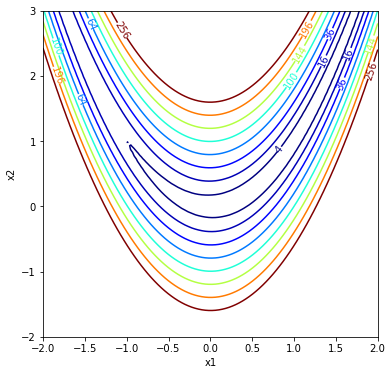

In [32]:
plt.figure(figsize=(6, 6)) 
CS = plt.contour(X1mesh, X2mesh, Z, np.arange(2,18,2)**2, cmap='jet', vmax=250) # fourth
# CS = plt.contour(X, Y, Z, np.arange(2,18,2)**2, cmap='jet', vmax=250) # fourth
# label the contours along the lines; without inline_spacing, too much white space 
plt.clabel(CS,inline_spacing=0,fmt='%d') 
plt.axis([-2,2,-2,3]) 
plt.xlabel('x1') 
plt.ylabel('x2') 
plt.show() 

## Question 2

In [4]:
import numpy as np 
import matplotlib.pyplot as plt  
from mpl_toolkits.mplot3d import axes3d 


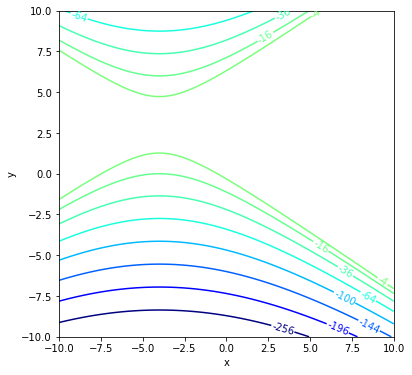

In [37]:
f = lambda x1, x2: 8*x1 + 12*x2 + x1**2 -2*x2**2
X1 = np.linspace(-10,10,300)
X2 = np.linspace(-10,10,300)
X1mesh, X2mesh = np.meshgrid(X1,X2)
Z = f(X1mesh, X2mesh)
plt.figure(figsize=(6, 6)) 


CS = plt.contour(X1mesh, X2mesh, Z, (-np.arange(2,18,2)**2)[::-1], cmap='jet', vmax=250) 
plt.clabel(CS,inline_spacing=0,fmt='%d') 
plt.axis([-10,10,-10,10]) 
plt.xlabel('x') 
plt.ylabel('y') 
plt.show() 

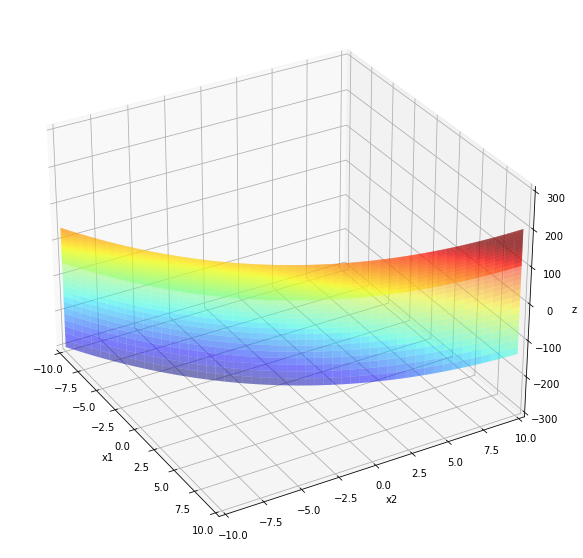

In [44]:
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection='3d', elev=30, azim=-30)
ax.plot_surface(X1, X2, Z, cmap='jet', alpha=0.5, vmax=150)
ax.set(xlabel='x1', ylabel='x2', zlabel='z', xlim=[-10,10], ylim=[-10,10], zlim=[-300, 300])
plt.show() 

## Question 3

In [44]:
import numpy as np 
from numpy.linalg import norm 
import matplotlib.pyplot as plt 
from scipy.optimize import minimize_scalar

In [45]:
def exact_steepest_decent_method(objFunc, gradObjFunc, x0, tol, maxIter):
    
    path      = [x0]
    k         = 0
    xk        = x0
    pk        = -gradObjFunc(x0)
    while norm(pk) > tol and k <= maxIter:
        def subproblem1D(alpha):
            return objFunc(xk + alpha * pk)
        res = minimize_scalar(subproblem1D) 
        xk  = xk + res.x * pk 
        pk  = -gradObjFunc(xk)
        k   = k + 1
        path.append(xk)
    path = np.array(path) # convert to array
        
    if norm(pk) <= tol:
        print("Found the minimizer at {x} with {iter} iterations successfully, gradient's norm is {nrm}.".format(x=xk,iter=k,nrm=norm(pk)))
    else:
        print("Unable to locate minimizer within maximum iterations, last position is at {x}, gradient's norm is {nrm}".format(x=xk,nrm=norm(pk)))
        
    return xk, k, path

In [46]:
def QObjFunc(x):    
    return (x[0] + x[1]**2)**2
def QGradObjFunc(x):
    return np.array([2*x[0] + 2*x[1]**2, 
                    4*x[1]**3 + 4*x[0]*x[1]])

In [51]:
x0      = np.array([1, 0])
tol     = 1e-9 
maxIter = 1e6 
alpha   = 0.5

In [52]:
 x_1, iter_1, path_1 = exact_steepest_decent_method(QObjFunc, QGradObjFunc, x0, tol, maxIter)

Found the minimizer at [2.22044605e-16 0.00000000e+00] with 1 iterations successfully, gradient's norm is 4.440892098500626e-16.


In [57]:
x0      = np.array([-1, 1])
tol     = 1e-9 
maxIter = 1e6 
alpha   = 0.5

In [58]:
 x_1, iter_1, path_1 = exact_steepest_decent_method(QObjFunc, QGradObjFunc, x0, tol, maxIter)

Found the minimizer at [-1  1] with 0 iterations successfully, gradient's norm is 0.0.


## Question 4

In [134]:
def fixed_step_steepest_decent_method(objFunc, gradObjFunc, alpha,  x0, tol, maxIter):
    path      = [x0]
    k         = 0
    xk        = x0
    pk        = -gradObjFunc(x0)
    while norm(pk) > tol and k <= maxIter:
        xk  = xk + alpha * pk 
        pk  = -gradObjFunc(xk)
        k   = k + 1
        path.append(xk)
        
    path = np.array(path) # convert to array
        
    if norm(pk) <= tol:
        print("Found the minimizer at {x} with {iter} iterations successfully, gradient's norm is {nrm}.".format(x=xk,iter=k,nrm=norm(pk)))
    else:
        print("Unable to locate minimizer within maximum iterations, last position is at {x}, gradient's norm is {nrm}".format(x=xk,nrm=norm(pk)))
        
    return xk, k, path

In [121]:
def QObjFunc(x):    
    return 100*(x[1] - x[0]**2)**2 + (1-x[0])**2
def QGradObjFunc(x):
    return np.array([400*x[0]**3 - 400*x[0]*x[1] -2 +2*x[0], 
                    -200*x[0]**2 + 200*x[1]])

In [137]:
x01      = np.array([1.2, 1.2])
tol     = 1e-8 
maxIter = 1e6 
alpha   = 1e-3

In [139]:
x_1, iter_1, path_1 = fixed_step_steepest_decent_method(QObjFunc, QGradObjFunc, alpha, x0, tol, maxIter)

Found the minimizer at [1.00000001 1.00000002] with 40801 iterations successfully, gradient's norm is 9.997849209810188e-09.


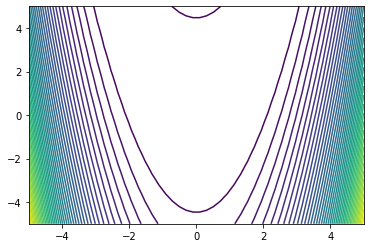

In [142]:
x1 = np.linspace(-5, 5, 50)
y1 = np.linspace(-5,5 , 50)
X1, Y1 = np.meshgrid(x1, y1)
# evaluate function
Z1 = QObjFunc([X1,Y1])
plt.contour(X1, Y1, Z1, 50)

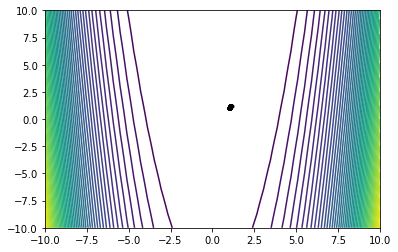

In [143]:
plt.contour(X, Y, Z, 50);
plt.plot(path_1[:,0],path_1[:,1],'-k', marker='.')

Find the larger alpha

In [145]:
x0      = np.array([1.2, 1.2])
tol     = 1e-8 
maxIter = 1e6 
alpha   = 1

In [146]:
x_2, iter_2, path_2 = fixed_step_steepest_decent_method(QObjFunc, QGradObjFunc, alpha, x0, tol, maxIter)

Unable to locate minimizer within maximum iterations, last position is at [-5.89854463e+270  1.20268875e+181], gradient's norm is nan


<ipython-input-121-90159732db2b>:4: RuntimeWarning: overflow encountered in double_scalars
  return np.array([400*x[0]**3 - 400*x[0]*x[1] -2 +2*x[0],
<ipython-input-121-90159732db2b>:4: RuntimeWarning: invalid value encountered in double_scalars
  return np.array([400*x[0]**3 - 400*x[0]*x[1] -2 +2*x[0],
<ipython-input-121-90159732db2b>:5: RuntimeWarning: overflow encountered in double_scalars
  -200*x[0]**2 + 200*x[1]])


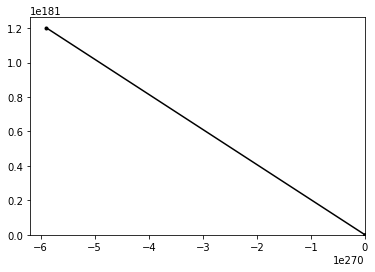

In [147]:
x2 = np.linspace(-5, 5, 50)
y2 = np.linspace(-5, 5, 50)
X2, Y2 = np.meshgrid(x2, y2)
Z2 = QObjFunc([X2,Y2])
plt.contour(X2, Y2, Z2, 50);
plt.plot(path_2[:,0],path_2[:,1],'-k', marker='.')

Start at x0 = (-1.2, 1)

In [148]:
x0      = np.array([-1.2, 1])
tol     = 1e-8 
maxIter = 1e6 
alpha   = 1e-3

In [149]:
x_3, iter_3, path_3 = fixed_step_steepest_decent_method(QObjFunc, QGradObjFunc, alpha, x0, tol, maxIter)

Found the minimizer at [0.99999999 0.99999998] with 43605 iterations successfully, gradient's norm is 9.999079369299886e-09.


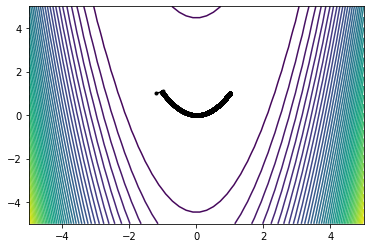

In [150]:
x3 = np.linspace(-5, 5, 50)
y3 = np.linspace(-5, 5, 50)
X3, Y3 = np.meshgrid(x3, y3)
Z3 = QObjFunc([X3,Y3])
plt.contour(X3, Y3, Z3, 50);
plt.plot(path_3[:,0],path_3[:,1],'-k', marker='.')